In [286]:
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 
import warnings 
import json
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
from sklearn.model_selection import train_test_split
from config import HYPERPARAMETERS


warnings.filterwarnings('ignore')

In [287]:
df = pd.read_csv('dataset/car_price_prediction.csv')

## EDA

In [288]:
df = df.drop('ID', axis=1)
df = df.drop('Cylinders',axis=1)

df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
0,13328,1399,LEXUS,RX 450,2010,Jeep,Yes,Hybrid,3.5,186005 km,Automatic,4x4,04-May,Left wheel,Silver,12
1,16621,1018,CHEVROLET,Equinox,2011,Jeep,No,Petrol,3,192000 km,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,-,HONDA,FIT,2006,Hatchback,No,Petrol,1.3,200000 km,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862,FORD,Escape,2011,Jeep,Yes,Hybrid,2.5,168966 km,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446,HONDA,FIT,2014,Hatchback,Yes,Petrol,1.3,91901 km,Automatic,Front,04-May,Left wheel,Silver,4


In [289]:
df.shape

(19237, 16)

In [290]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19237 entries, 0 to 19236
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Price             19237 non-null  int64 
 1   Levy              19237 non-null  object
 2   Manufacturer      19237 non-null  object
 3   Model             19237 non-null  object
 4   Prod. year        19237 non-null  int64 
 5   Category          19237 non-null  object
 6   Leather interior  19237 non-null  object
 7   Fuel type         19237 non-null  object
 8   Engine volume     19237 non-null  object
 9   Mileage           19237 non-null  object
 10  Gear box type     19237 non-null  object
 11  Drive wheels      19237 non-null  object
 12  Doors             19237 non-null  object
 13  Wheel             19237 non-null  object
 14  Color             19237 non-null  object
 15  Airbags           19237 non-null  int64 
dtypes: int64(3), object(13)
memory usage: 2.3+ MB


In [291]:
df["Levy"].eq("-").sum()

np.int64(5819)

In [292]:
print(df[df["Prod. year"] < 1980].count())
print("--------------------------------------")
# print(df[df["Cylinders"] > 8].count())

print("--------------------------------------")
print(df[df["Price"] >= 500])


Price               23
Levy                23
Manufacturer        23
Model               23
Prod. year          23
Category            23
Leather interior    23
Fuel type           23
Engine volume       23
Mileage             23
Gear box type       23
Drive wheels        23
Doors               23
Wheel               23
Color               23
Airbags             23
dtype: int64
--------------------------------------
--------------------------------------
       Price  Levy   Manufacturer    Model  Prod. year   Category  \
0      13328  1399          LEXUS   RX 450        2010       Jeep   
1      16621  1018      CHEVROLET  Equinox        2011       Jeep   
2       8467     -          HONDA      FIT        2006  Hatchback   
3       3607   862           FORD   Escape        2011       Jeep   
4      11726   446          HONDA      FIT        2014  Hatchback   
...      ...   ...            ...      ...         ...        ...   
19231   5802  1055  MERCEDES-BENZ    E 350        2013    

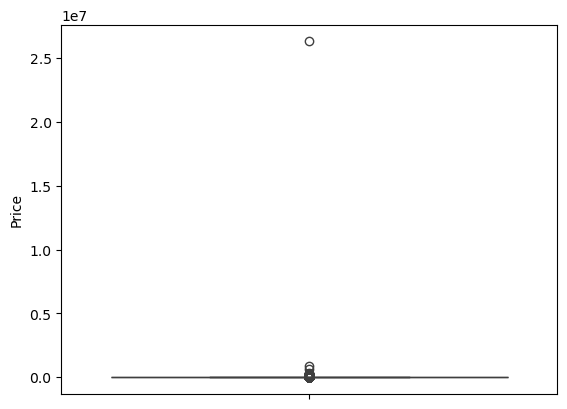

In [293]:
sns.boxplot(y=df["Price"])
plt.show()

In [294]:
df.drop_duplicates(inplace=True) # Remove duplicate records.

In [295]:
df = df[df["Price"] >= 1000] # Remove unrealistic prices (< 500).

In [296]:
columns = ["Price"]

for col in columns:

    Q1 = df[col].quantile(.25)

    Q3 = df[col].quantile(.75)

    IQR = Q3-Q1

    lower = Q1-1.5*IQR

    upper = Q3+1.5*IQR

    df = df[
        (df[col]>=lower) &
        (df[col]<=upper)
    ]

<Axes: ylabel='Price'>

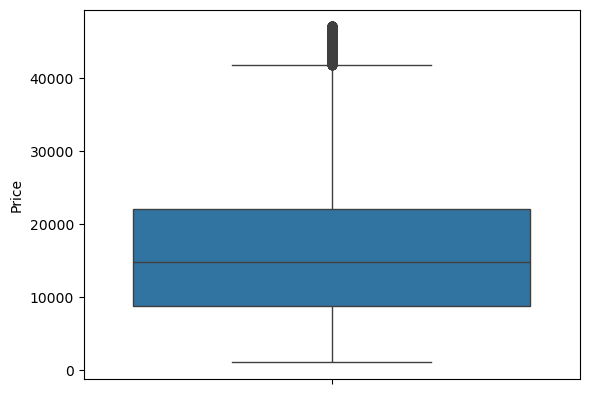

In [297]:
sns.boxplot(y=df["Price"])

In [298]:
df = df[df["Prod. year"] >= 1980]

In [299]:
df["Levy"].replace("-", np.nan, inplace=True)
df["Levy"] = pd.to_numeric(df["Levy"])

In [300]:
def get_first_value(value):
    return str(value).split()[0]

df["Mileage"] = df["Mileage"].apply(get_first_value)

In [301]:
df = df[df["Airbags"] <= 8]

In [302]:
df["Engine volume"] = df["Engine volume"].apply(get_first_value)
df['Engine volume'] = df['Engine volume'].astype(float)

In [303]:
df['Leather interior'].value_counts()

Leather interior
Yes    5677
No     3922
Name: count, dtype: int64

In [304]:
df['Leather interior'] = df['Leather interior'].map({"No" : 0,"Yes" : 1})

In [305]:
df.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,0,Petrol,3.0,192000,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,NaN,HONDA,FIT,2006,Hatchback,0,Petrol,1.3,200000,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862.0,FORD,Escape,2011,Jeep,1,Hybrid,2.5,168966,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446.0,HONDA,FIT,2014,Hatchback,1,Petrol,1.3,91901,Automatic,Front,04-May,Left wheel,Silver,4
5,39493,891.0,HYUNDAI,Santa FE,2016,Jeep,1,Diesel,2.0,160931,Automatic,Front,04-May,Left wheel,White,4


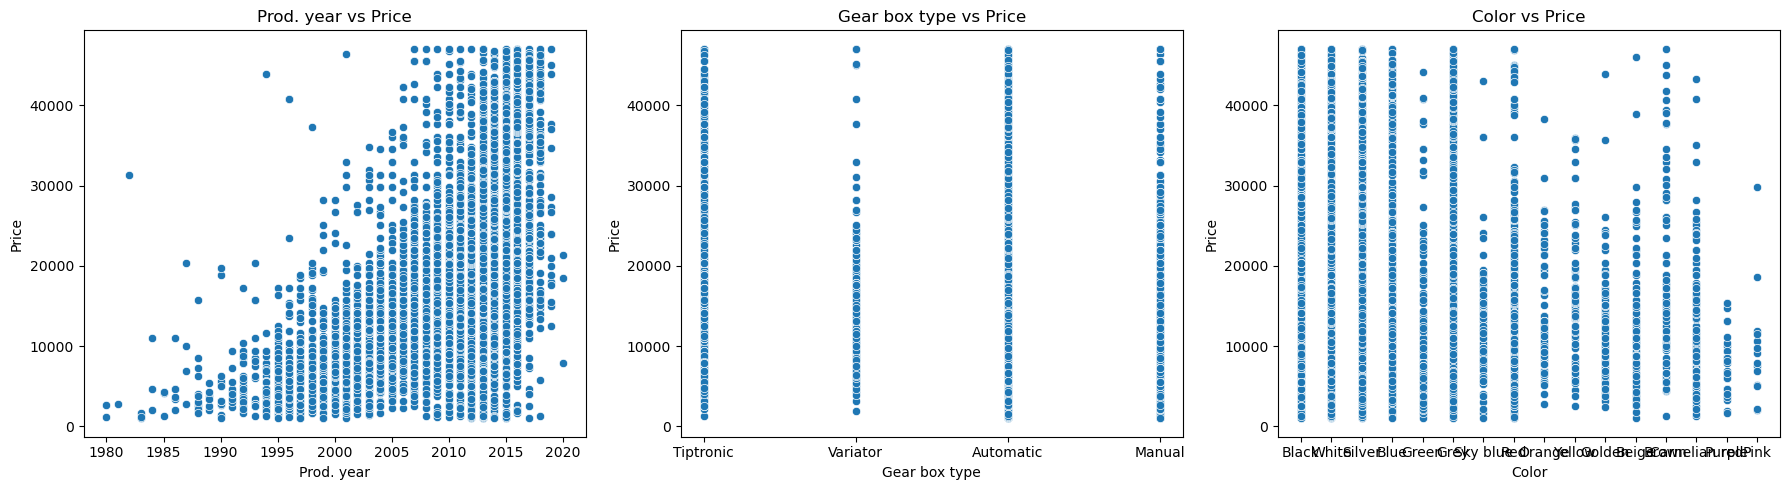

In [306]:
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 5))

sns.scatterplot(data=df, x="Prod. year", y="Price", ax=axes[0])
axes[0].set_title("Prod. year vs Price")

sns.scatterplot(data=df, x="Gear box type", y="Price", ax=axes[1])
axes[1].set_title("Gear box type vs Price")

sns.scatterplot(data=df, x="Color", y="Price", ax=axes[2])
axes[2].set_title("Color vs Price")

plt.tight_layout()
plt.show()

In [307]:
df.isnull().sum()

Price                  0
Levy                3995
Manufacturer           0
Model                  0
Prod. year             0
Category               0
Leather interior       0
Fuel type              0
Engine volume          0
Mileage                0
Gear box type          0
Drive wheels           0
Doors                  0
Wheel                  0
Color                  0
Airbags                0
dtype: int64

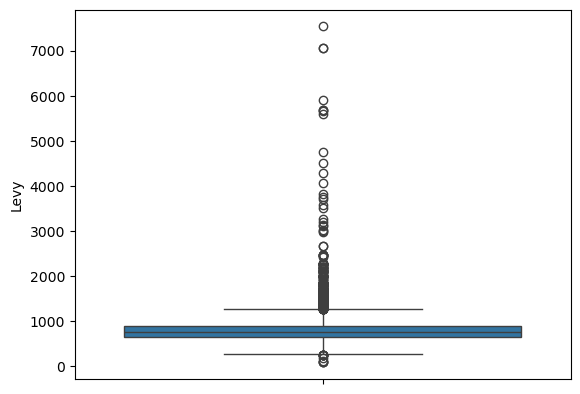

In [308]:
sns.boxplot(y=df["Levy"])
plt.show()

In [309]:
df.nunique()

Price               1697
Levy                 405
Manufacturer          52
Model               1083
Prod. year            41
Category              11
Leather interior       2
Fuel type              7
Engine volume         55
Mileage             4815
Gear box type          4
Drive wheels           3
Doors                  3
Wheel                  2
Color                 16
Airbags                9
dtype: int64

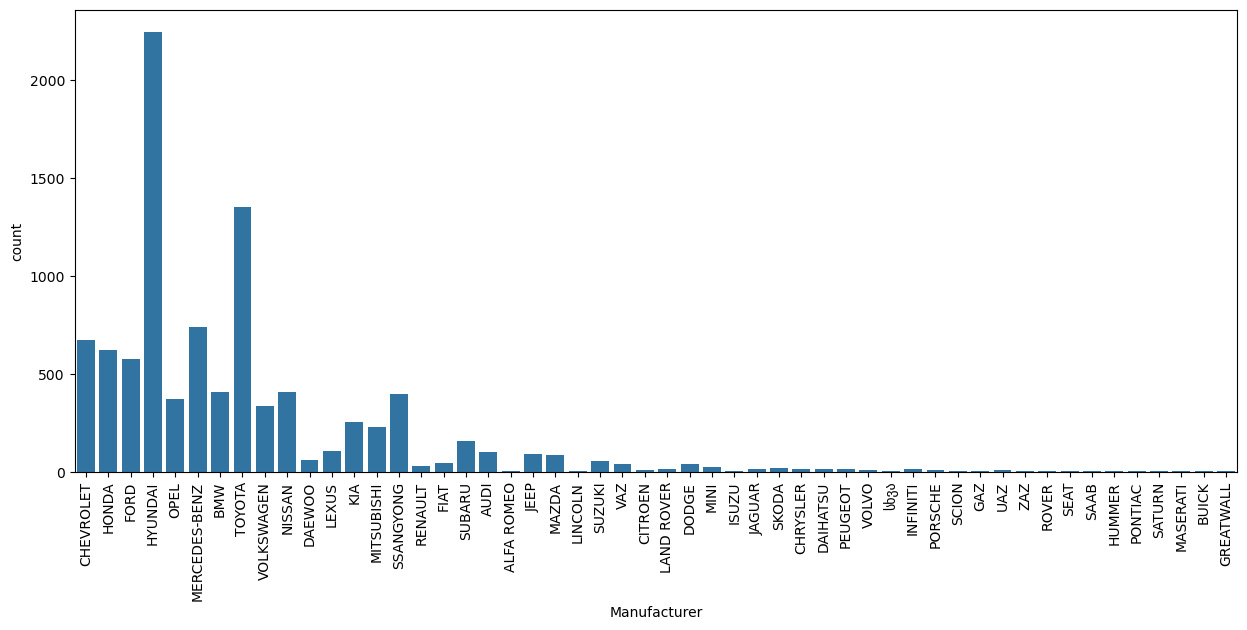

In [310]:
plt.figure(figsize=(15, 6))
sns.countplot(x="Manufacturer", data=df)
plt.xticks(rotation=90)
plt.show()

<Axes: xlabel='Price', ylabel='Count'>

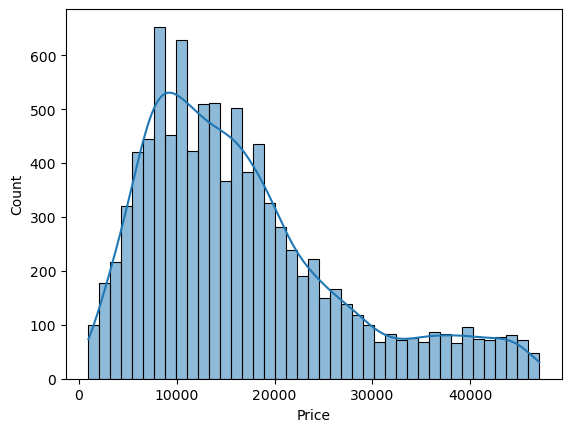

In [311]:
sns.histplot(df["Price"], kde=True)

<Axes: >

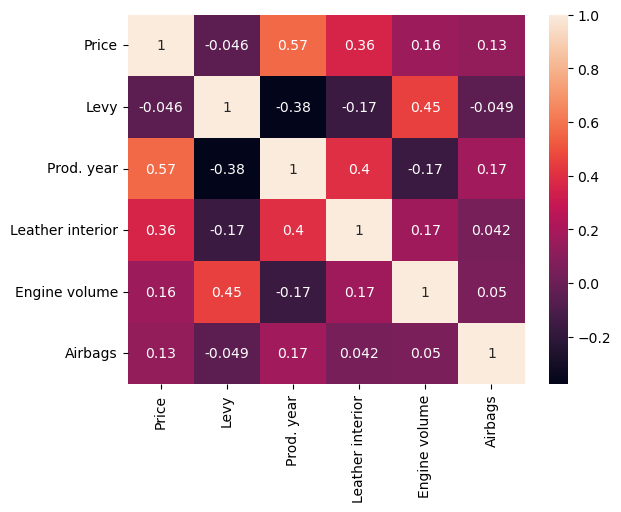

In [312]:
sns.heatmap(df.corr(numeric_only=True), annot=True)

## data cleaning and preprocession wiht feature engineering

In [313]:
df_cleaned = df.copy()

In [314]:
df_cleaned.head()

,Price,Levy,Manufacturer,Model,Prod. year,Category,Leather interior,Fuel type,Engine volume,Mileage,Gear box type,Drive wheels,Doors,Wheel,Color,Airbags
1,16621,1018.0,CHEVROLET,Equinox,2011,Jeep,0,Petrol,3.0,192000,Tiptronic,4x4,04-May,Left wheel,Black,8
2,8467,NaN,HONDA,FIT,2006,Hatchback,0,Petrol,1.3,200000,Variator,Front,04-May,Right-hand drive,Black,2
3,3607,862.0,FORD,Escape,2011,Jeep,1,Hybrid,2.5,168966,Automatic,4x4,04-May,Left wheel,White,0
4,11726,446.0,HONDA,FIT,2014,Hatchback,1,Petrol,1.3,91901,Automatic,Front,04-May,Left wheel,Silver,4
5,39493,891.0,HYUNDAI,Santa FE,2016,Jeep,1,Diesel,2.0,160931,Automatic,Front,04-May,Left wheel,White,4


In [315]:
df_cleaned.corr(numeric_only=True)["Price"].sort_values()

Levy               -0.045892
Airbags             0.128751
Engine volume       0.155317
Leather interior    0.358302
Prod. year          0.566030
Price               1.000000
Name: Price, dtype: float64

In [316]:
y = df_cleaned['Price']

In [317]:
X = df_cleaned.drop(columns=['Price'],axis=1)

In [318]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from category_encoders import TargetEncoder 

# Create Column Transformer with 3 types of transformers
num_features = X.select_dtypes(exclude="object").columns
cat_features = X.select_dtypes(include="object").columns

# Device into encoding part 
target_encode_cols = ['Manufacturer', 'Model', 'Color']
ohe_cols = [col for col in X.select_dtypes(include="object").columns if col not in target_encode_cols]
num_features = X.select_dtypes(exclude="object").columns


preprocessor = ColumnTransformer(
    transformers=[
        ("Numeric_Scale", StandardScaler(), num_features),
        ("OneHot_Encode", OneHotEncoder(handle_unknown="ignore", drop="first"), ohe_cols),
        ("Target_Encode", TargetEncoder(handle_unknown="value"), target_encode_cols)
    ]
)

In [319]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
X_train.shape, X_test.shape

((7679, 15), (1920, 15))

In [320]:
median_levy = X_train.groupby("Category")["Levy"].median()

X_train["Levy"] = X_train.apply(
    lambda row: median_levy[row["Category"]]
    if pd.isna(row["Levy"])
    else row["Levy"],
    axis=1
)

X_test["Levy"] = X_test.apply(
    lambda row: median_levy.get(row["Category"], X_train["Levy"].median())
    if pd.isna(row["Levy"])
    else row["Levy"],
    axis=1
)

In [321]:
# print("Train NaN:")
# print(X_train.isnull().sum())

# print("Test NaN:")
# print(X_test.isnull().sum())

train_index = X_train["Levy"].notna()
X_train = X_train[train_index]
y_train = y_train[train_index] 

train_index = X_test["Levy"].notna()
X_test = X_test[train_index]
y_test = y_test[train_index] 

In [322]:
X_train = preprocessor.fit_transform(X_train, y_train)
X_test = preprocessor.transform(X_test)

In [323]:
X.shape

(9599, 15)

# split into train/test data 

In [324]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import cross_val_score
import joblib

In [325]:
def evaluate_model(y_true, y_pred):
    return {
        "MAE": round(float(mean_absolute_error(y_true, y_pred)), 4),
        "MSE": round(float(mean_squared_error(y_true, y_pred)), 4),
        "RMSE": round(float(np.sqrt(mean_squared_error(y_true, y_pred))), 4),
        "R2": round(float(r2_score(y_true, y_pred)), 4)
    }

In [326]:
def tune_model(model_name, model, X_train, y_train):

    if model_name not in HYPERPARAMETERS:
        return model

    print(f"Tuning {model_name}...")

    random_search = RandomizedSearchCV(

        estimator=model,

        param_distributions=HYPERPARAMETERS[model_name],

        n_iter=20,

        cv=5,

        scoring="r2",

        random_state=42,

        n_jobs=-1

    )

    random_search.fit(X_train, y_train)

    print("Best Parameters :", random_search.best_params_)

    print("Best CV Score :", random_search.best_score_)

    return random_search.best_estimator_

In [327]:
def train_models(models, X_train, X_test, y_train, y_test):

    results = {}

    best_model = None
    best_model_name = ""
    best_score = -1

    for name, model in models.items():

        print(f"\nTraining {name}...")
        cv_scores = cross_val_score( model,X_train,y_train,cv=5,scoring="r2")
        model = tune_model(name, model, X_train, y_train)
        
        model.fit(X_train, y_train)

        train_pred = model.predict(X_train)
        test_pred = model.predict(X_test)

        train_mae = mean_absolute_error(y_train, train_pred)
        test_mae = mean_absolute_error(y_test, test_pred)

        train_mse = mean_squared_error(y_train, train_pred)
        test_mse = mean_squared_error(y_test, test_pred)

        train_rmse = np.sqrt(train_mse)
        test_rmse = np.sqrt(test_mse)

        train_r2 = r2_score(y_train, train_pred)
        test_r2 = r2_score(y_test, test_pred)

        # Save Best Model
        if test_r2 > best_score:

            best_score = test_r2
            best_model = model
            best_model_name = name

        results[name] = {

            "train":{

                "MAE":round(train_mae,4),
                "MSE":round(train_mse,4),
                "RMSE":round(train_rmse,4),
                "R2":round(train_r2,4)

            },

            "test":{

                "MAE":round(test_mae,4),
                "MSE":round(test_mse,4),
                "RMSE":round(test_rmse,4),
                "R2":round(test_r2,4)

            }

        }

    print("="*60)
    print("Best Model :", best_model_name)
    print("Best Test R2 :", round(best_score,4))
    print("="*60)

    joblib.dump(best_model, "model.pkl")

    return results, best_model

In [328]:
def save_results(results, file_name="model_results.json"):
    with open(file_name, "w") as file:
        json.dump(results, file, indent=4)

In [329]:
models = {
    "Linear Regression": LinearRegression(),
    "Lasso": Lasso(alpha=1.0, max_iter=10000),
    "Ridge": Ridge(),
    "K-Neighbors Regressor": KNeighborsRegressor(),
    "Decision Tree": DecisionTreeRegressor(random_state=42),
    "Random Forest Regressor": RandomForestRegressor(random_state=42),
    "XGBRegressor": XGBRegressor(random_state=42), 
    "CatBoosting Regressor": CatBoostRegressor(verbose=False),
    "AdaBoost Regressor": AdaBoostRegressor(random_state=42)
}


In [330]:
results, best_model = train_models(models, X_train, X_test, y_train,  y_test)
save_results(results)


Training Linear Regression...

Training Lasso...

Training Ridge...

Training K-Neighbors Regressor...

Training Decision Tree...

Training Random Forest Regressor...
Tuning Random Forest Regressor...
Best Parameters : {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV Score : 0.7517488754033823

Training XGBRegressor...
Tuning XGBRegressor...
Best Parameters : {'subsample': 0.8, 'n_estimators': 300, 'max_depth': 7, 'learning_rate': 0.1, 'colsample_bytree': 1.0}
Best CV Score : 0.7985008955001831

Training CatBoosting Regressor...
Tuning CatBoosting Regressor...
Best Parameters : {'learning_rate': 0.1, 'l2_leaf_reg': 1, 'iterations': 500, 'depth': 6}
Best CV Score : 0.7747322213565554

Training AdaBoost Regressor...
Best Model : XGBRegressor
Best Test R2 : 0.7531


In [331]:
import joblib

joblib.dump(best_model,"model.pkl")

['model.pkl']

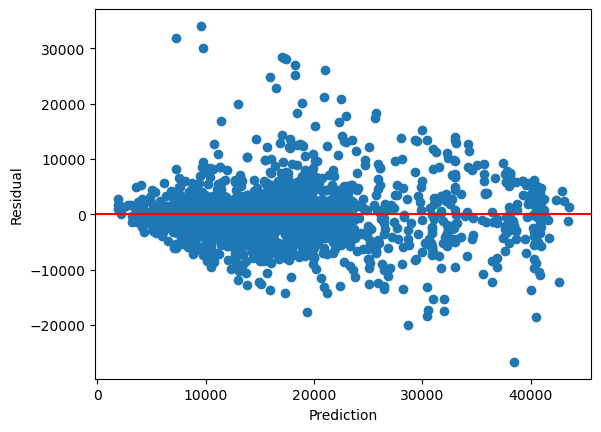

In [332]:
prediction = best_model.predict(X_test)
residual = y_test - prediction
plt.scatter(prediction,residual)
plt.axhline(y=0,color='red')
plt.xlabel("Prediction")
plt.ylabel("Residual")
plt.show()

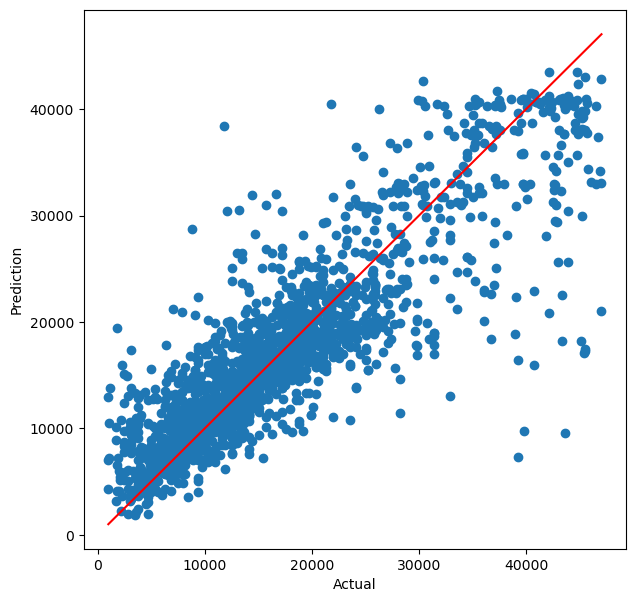

In [333]:
plt.figure(figsize=(7,7))
plt.scatter(y_test,prediction)
plt.plot(
    [y_test.min(),y_test.max()],
    [y_test.min(),y_test.max()],
    color="red"
)
plt.xlabel("Actual")
plt.ylabel("Prediction")
plt.show()

In [334]:
comparison_df = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": prediction
})

comparison_df["Difference"] = comparison_df["Actual Price"] - comparison_df["Predicted Price"]

comparison_df["Absolute Error"] = comparison_df["Difference"].abs()

comparison_df["Percentage Error"] = (
    comparison_df["Absolute Error"] / comparison_df["Actual Price"]
) * 100

comparison_df = comparison_df.round(2)

comparison_df.head(20)

,Actual Price,Predicted Price,Difference,Absolute Error,Percentage Error
0,7056,21205.779297,-14149.78,14149.78,200.54
1,4077,6166.810059,-2089.81,2089.81,51.26
2,3763,3670.899902,92.10,92.10,2.45
3,6272,7998.370117,-1726.37,1726.37,27.53
4,26030,16032.849609,9997.15,9997.15,38.41
5,9408,5323.209961,4084.79,4084.79,43.42
6,14426,13198.040039,1227.96,1227.96,8.51
7,11604,10634.070312,969.93,969.93,8.36
8,35902,29965.470703,5936.53,5936.53,16.54
9,15053,11913.839844,3139.16,3139.16,20.85
